<a href="https://colab.research.google.com/github/rahafalnjjar49-cloud/Breast-Cancer-Wisconsin/blob/main/Breast_Cancer_Wisconsin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
                              roc_curve, auc, ConfusionMatrixDisplay)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(42)
np.random.seed(42)

print("إصدار TensorFlow:", tf.__version__)

إصدار TensorFlow: 2.20.0


In [ ]:
from google.colab import files
uploaded= files.upload()
df_raw = pd.read_csv('data.csv')

print("شكل البيانات    :", df_raw.shape)
df_raw.head()

Saving data.csv to data.csv
شكل البيانات    : (569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [ ]:
df = df_raw.drop(columns=['id', 'Unnamed: 32'], errors='ignore')

df['diagnosis'] = df['diagnosis'].map({'M': 0, 'B': 1})

target_names = ['malignant', 'benign']

X = df.drop(columns=['diagnosis']).values
y = df['diagnosis'].values
feature_names = df.drop(columns=['diagnosis']).columns.tolist()

print("شكل بيانات الخصائص X:", X.shape)
print("شكل بيانات الأهداف y:", y.shape)
print("أسماء الفئات:", target_names)
df.head()

شكل بيانات الخصائص X: (569, 30)
شكل بيانات الأهداف y: (569,)
أسماء الفئات: ['malignant', 'benign']


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,0,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,0,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,0,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,0,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


diagnosis
1    357
0    212
Name: count, dtype: int64


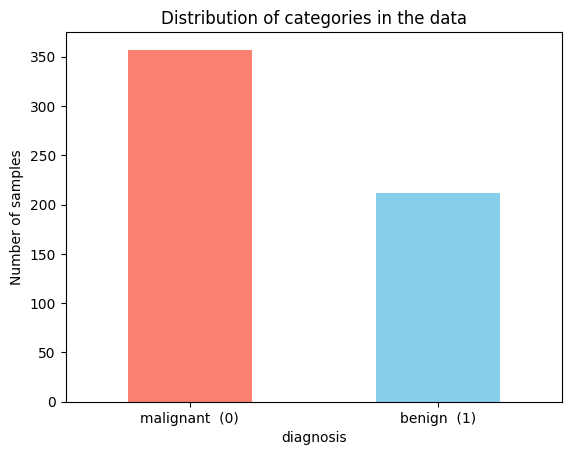

In [ ]:
print(df['diagnosis'].value_counts())
df['diagnosis'].value_counts().plot(kind='bar', color=['salmon', 'skyblue'])
plt.xticks([0, 1], ['malignant  (0)', 'benign  (1)'], rotation=0)
plt.title('Distribution of categories in the data')
plt.ylabel('Number of samples')
plt.show()

In [ ]:
print("Number of missing values ​​in the entire dataset:", df.isnull().sum().sum())

Number of missing values ​​in the entire dataset: 0


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training data size:", X_train_scaled.shape)
print("Test data size:", X_test_scaled.shape)

Training data size: (455, 30)
Test data size: (114, 30)


In [ ]:
model = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(16, activation='relu', name='hidden_layer_1'),
    layers.Dense(8, activation='relu', name='hidden_layer_2'),
    layers.Dense(1, activation='sigmoid', name='output_layer')
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 16)             │           496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 641 (2.50 KB)

 Trainable params: 641 (2.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True
)

history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7720 - loss: 0.5784 - val_accuracy: 0.7582 - val_loss: 0.5660
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8297 - loss: 0.4702 - val_accuracy: 0.8242 - val_loss: 0.4621
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8846 - loss: 0.3666 - val_accuracy: 0.9341 - val_loss: 0.3613
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9313 - loss: 0.2768 - val_accuracy: 0.9451 - val_loss: 0.2768
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9396 - loss: 0.2164 - val_accuracy: 0.9451 - val_loss: 0.2194
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9396 - loss: 0.1761 - val_accuracy: 0.9451 - val_loss: 0.1793
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9505 - loss: 0.1477 - val_accuracy: 0.9560 - val_loss: 0.1513
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9560 - loss: 0.1278 - val_accuracy: 0.9560 - val_loss

In [ ]:
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"(Test Accuracy): {test_accuracy:.4f}")
print(f"(Test Loss): {test_loss:.4f}")

y_pred_prob = model.predict(X_test_scaled, verbose=0).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)

print("\nتقرير التصنيف:\n")
print(classification_report(y_test, y_pred, target_names=target_names))

(Test Accuracy): 0.9649
(Test Loss): 0.0932

تقرير التصنيف:

              precision    recall  f1-score   support

   malignant       0.93      0.98      0.95        42
      benign       0.99      0.96      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.97      0.96       114
weighted avg       0.97      0.96      0.97       114



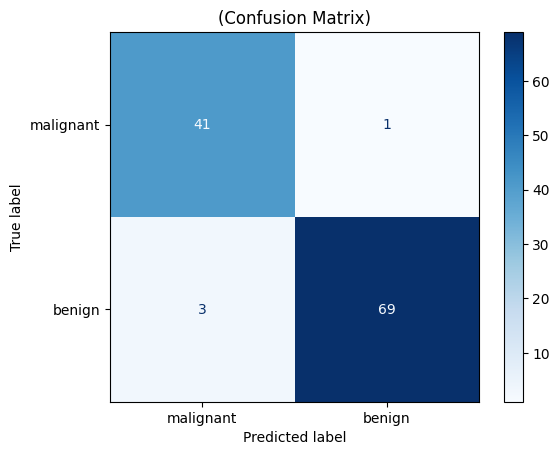

In [ ]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(cmap='Blues')
plt.title('(Confusion Matrix)')
plt.show()

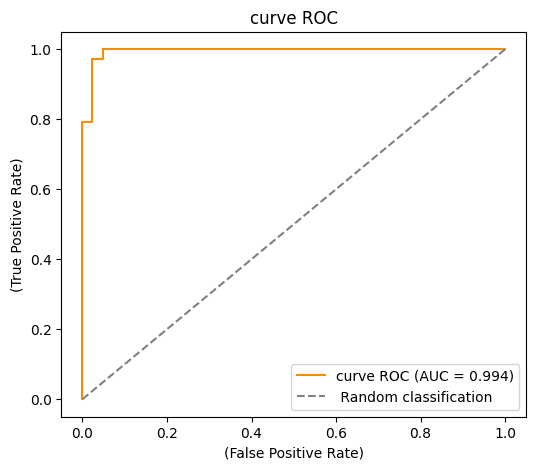

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'curve ROC (AUC = {roc_auc:.3f})', color='darkorange')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label=' Random classification')
plt.xlabel('(False Positive Rate)')
plt.ylabel('(True Positive Rate)')
plt.title('curve ROC')
plt.legend()
plt.show()

In [ ]:
model_v2 = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(16, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid')
])

model_v2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0005),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop_v2 = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=15, restore_best_weights=True
)

history_v2 = model_v2.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=150,
    batch_size=32,
    callbacks=[early_stop_v2],
    verbose=0
)

test_loss_v2, test_accuracy_v2 = model_v2.evaluate(X_test_scaled, y_test, verbose=0)
print(f"The First Model  -> Test accuracy : {test_accuracy:.4f}")
print(f"The improved model -> Test accuracy : {test_accuracy_v2:.4f}")

The First Model  -> Test accuracy : 0.9649
The improved model -> Test accuracy : 0.9737


In [ ]:
sample_indices = [0, 1, 2, 3, 4]
samples = X_test_scaled[sample_indices]
true_labels = y_test[sample_indices]

pred_probs = model.predict(samples, verbose=0).ravel()
pred_labels = (pred_probs > 0.5).astype(int)

results = pd.DataFrame({
    'احتمال أن يكون حميدًا': pred_probs.round(4),
    'التصنيف المتوقع': [target_names[p] for p in pred_labels],
    'التصنيف الحقيقي': [target_names[t] for t in true_labels],
    'متطابق؟': pred_labels == true_labels
})
results

,احتمال أن يكون حميدًا,التصنيف المتوقع,التصنيف الحقيقي,متطابق؟
0,0.0000,malignant,malignant,True
1,1.0000,benign,benign,True
2,0.0005,malignant,malignant,True
3,0.1313,malignant,benign,False
4,0.0000,malignant,malignant,True
